# LightGBM fitting and testing

In [5]:
#df = pd.read_parquet('Mistral_512tok.parquet')
df = pd.read_parquet('Mistral_512tok_50prompts.parquet')

## Cross-prompt geenralization

In [26]:
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# ── Classificazione feature ───────────────────────────────────────────────────
MODEL_DEP_FEATURES = [
    "effective_rank_Wq", "r95_Wq",
    "effective_rank_Wk", "r95_Wk",
    "effective_rank_Wv", "r95_Wv",
    "gini_left_Wq", "gini_right_Wq",
    "gini_left_Wk", "gini_right_Wk",
    "rope_pair_var_Wq", "rope_pair_var_Wk",
    "rope_pair_max_ratio_Wq", "rope_pair_max_ratio_Wk",
    "rope_freq_com_Wq", "rope_freq_com_Wk",
    #"rmsnorm_gamma_norm",
    "compute_WqRWk_alignment_delta_0",
]

INPUT_DEP_FEATURES = [
    #"effective_rank_H", "r95_H",
    #"effective_rank_Q", "r95_Q",
    #"effective_rank_K", "r95_K",
    "q_sim_consecutive", "k_sim_consecutive",
    #"svd_alignment_H_Wq", "svd_alignment_H_Wk",
]

#TARGET = "attention_gini"
TARGET = "sink_mass_token_0"

FEATURE_SETS = {
    "offline": MODEL_DEP_FEATURES,
    "oracle":  MODEL_DEP_FEATURES + INPUT_DEP_FEATURES,
}

# ── Split deterministico per prompt ──────────────────────────────────────────
def split_by_prompt(df, val_frac=0.10, test_frac=0.10, seed=42):
    prompts = sorted(df["prompt_id"].unique())
    rng = np.random.default_rng(seed)
    rng.shuffle(prompts := np.array(prompts))

    n = len(prompts)
    n_test = int(n * test_frac)
    n_val  = int(n * val_frac)

    test_prompts  = set(prompts[:n_test])
    val_prompts   = set(prompts[n_test:n_test + n_val])
    train_prompts = set(prompts[n_test + n_val:])

    return (
        df[df["prompt_id"].isin(train_prompts)].copy(),
        df[df["prompt_id"].isin(val_prompts)].copy(),
        df[df["prompt_id"].isin(test_prompts)].copy(),
    )

# ── Baseline: media del target per testa nel train ───────────────────────────
def head_mean_baseline(df_train, df_test, target=TARGET):
    head_means = (df_train.groupby(["layer_idx", "head_idx"])[target]
                           .mean()
                           .rename("pred_baseline"))
    test_with_pred = df_test.merge(
        head_means.reset_index(), on=["layer_idx", "head_idx"], how="left"
    )
    # fallback: global mean per teste mai viste in train (non capita in exp1)
    global_mean = df_train[target].mean()
    test_with_pred["pred_baseline"] = test_with_pred["pred_baseline"].fillna(global_mean)
    return test_with_pred["pred_baseline"].values

# ── Training con early stopping su val ───────────────────────────────────────
def train_lgbm(df_train, df_val, features, target=TARGET):
    X_tr, y_tr = df_train[features].values, df_train[target].values
    X_va, y_va = df_val[features].values,   df_val[target].values

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_va, label=y_va, reference=dtrain)

    params = {
        "objective":        "regression_l1",   # MAE loss — robusta agli outlier
        "metric":           "mae",
        "learning_rate":    0.05,
        "num_leaves":       31,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq":     5,
        "min_child_samples": 20,
        "verbose":          -1,
        "seed":             42,
    }

    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=-1),
    ]

    model = lgb.train(
        params, dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=callbacks,
    )
    return model

# ── Valutazione ───────────────────────────────────────────────────────────────
def evaluate(model, df_test, features, target=TARGET, df_train=None):
    X_te = df_test[features].values
    y_te = df_test[target].values
    pred = model.predict(X_te)

    results = {
        "R2":  r2_score(y_te, pred),
        "MAE": mean_absolute_error(y_te, pred),
    }

    # Baseline confronto
    if df_train is not None:
        pred_base = head_mean_baseline(df_train, df_test, target)
        results["MAE_baseline"] = mean_absolute_error(y_te, pred_base)
        results["MAE_improvement"] = results["MAE_baseline"] - results["MAE"]

    # MAE per prompt_source (Wikitext vs Random)
    if "prompt_source" in df_test.columns:
        for src in df_test["prompt_source"].unique():
            mask = df_test["prompt_source"] == src
            results[f"MAE_{src}"] = mean_absolute_error(y_te[mask], pred[mask])

    # MAE per quartile di layer (struttura gerarchica)
    layers = sorted(df_test["layer_idx"].unique())
    q_size = len(layers) // 4
    layer_to_q = {l: min(i // q_size, 3) for i, l in enumerate(layers)}
    df_test = df_test.copy()
    df_test["layer_quartile"] = df_test["layer_idx"].map(layer_to_q)
    for q in range(4):
        mask = df_test["layer_quartile"] == q
        if mask.sum() > 0:
            results[f"MAE_Q{q+1}"] = mean_absolute_error(y_te[mask], pred[mask])

    df_test["pred"] = pred
    df_test["residual"] = y_te - pred
    return results, df_test

# ── Esecuzione completa ───────────────────────────────────────────────────────
def run_cross_prompt_experiment(df, prompt_sources=None):
    if prompt_sources:
        df = df[df["prompt_source"].isin(prompt_sources)].copy()

    df_train, df_val, df_test = split_by_prompt(df)
    print(f"Train: {len(df_train):,} obs ({df_train['prompt_id'].nunique()} prompts)")
    print(f"Val:   {len(df_val):,} obs ({df_val['prompt_id'].nunique()} prompts)")
    print(f"Test:  {len(df_test):,} obs ({df_test['prompt_id'].nunique()} prompts)")

    all_results = {}
    for variant_name, features in FEATURE_SETS.items():
        feats_available = [f for f in features if f in df.columns]
        print(f"\n── Variante: {variant_name} ({len(feats_available)} features) ──")

        model = train_lgbm(df_train, df_val, feats_available)
        metrics, df_pred = evaluate(model, df_test, feats_available, df_train=df_train)

        print(f"  R²:               {metrics['R2']:.4f}")
        print(f"  MAE (model):      {metrics['MAE']:.5f}")
        if "MAE_baseline" in metrics:
            print(f"  MAE (baseline):   {metrics['MAE_baseline']:.5f}")
            print(f"  Improvement:      {metrics['MAE_improvement']:.5f}")

        all_results[variant_name] = {
            "model": model,
            "metrics": metrics,
            "predictions": df_pred,
            "features": feats_available,
        }

    return all_results

# ── Run ───────────────────────────────────────────────────────────────────────
results_cp = run_cross_prompt_experiment(df)

Train: 81,920 obs (80 prompts)
Val:   10,240 obs (10 prompts)
Test:  10,240 obs (10 prompts)

── Variante: offline (17 features) ──
  R²:               0.7216
  MAE (model):      0.07984
  MAE (baseline):   0.07975
  Improvement:      -0.00009

── Variante: oracle (19 features) ──
  R²:               0.9159
  MAE (model):      0.04124
  MAE (baseline):   0.07975
  Improvement:      0.03851


In [ ]:
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_top_features(results_cp, top_n=15):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, (variant_name, res) in zip(axes, results_cp.items()):
        model    = res["model"]
        features = res["features"]
        df_pred  = res["predictions"]

        # SHAP values sul test set
        explainer   = shap.TreeExplainer(model)
        X_test      = df_pred[features].values
        shap_vals   = explainer.shap_values(X_test)        # (n_obs, n_features)

        # Mean absolute SHAP per feature
        mean_abs_shap = np.abs(shap_vals).mean(axis=0)
        order         = np.argsort(mean_abs_shap)[::-1][:top_n]

        feat_names_ord  = [features[i] for i in order]
        shap_vals_ord   = mean_abs_shap[order]

        # Colore per categoria
        colors = [
            "#2E86AB" if f in MODEL_DEP_FEATURES else "#E84855"
            for f in feat_names_ord
        ]

        bars = ax.barh(
            range(len(feat_names_ord))[::-1],
            shap_vals_ord,
            color=colors, alpha=0.88, edgecolor="none", height=0.65,
        )
        ax.set_yticks(range(len(feat_names_ord))[::-1])
        ax.set_yticklabels(feat_names_ord, fontsize=9)
        ax.set_xlabel("Mean |SHAP value|", fontsize=9)
        ax.set_title(
            f"Variante: {variant_name}\n"
            f"R²={res['metrics']['R2']:.4f}  MAE={res['metrics']['MAE']:.5f}",
            fontsize=10, fontweight="bold"
        )
        ax.grid(axis="x", lw=0.4, alpha=0.5)
        ax.spines[["top", "right"]].set_visible(False)

        # Legenda colori
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor="#2E86AB", label="model-dependent"),
            Patch(facecolor="#E84855", label="input-dependent"),
        ]
        ax.legend(handles=legend_elements, fontsize=8, loc="upper left")

    fig.suptitle(
        "Top feature importance — Experiment 1: Cross-Prompt\nTarget: attention_gini  |  Model: Mistral-7B",
        fontsize=11, fontweight="bold"
    )
    plt.show()


plot_top_features(results_cp, top_n=15)

In [28]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# ── Feature sets ──────────────────────────────────────────────────────────────
MODEL_DEP_FEATURES = [
    "effective_rank_Wq", "r95_Wq",
    "effective_rank_Wk", "r95_Wk",
    "effective_rank_Wv", "r95_Wv",
    "gini_left_Wq",  "gini_right_Wq",
    "gini_left_Wk",  "gini_right_Wk",
    "rope_pair_var_Wq",       "rope_pair_var_Wk",
    "rope_pair_max_ratio_Wq", "rope_pair_max_ratio_Wk",
    "rope_freq_com_Wq",       "rope_freq_com_Wk",
    "compute_WqRWk_alignment_delta_0",
]

INPUT_DEP_FEATURES = [
    "q_sim_consecutive",
    "k_sim_consecutive",
]

# ── Tutti i target da valutare ────────────────────────────────────────────────
ALL_TARGETS = [
    # Attention map structure
    "attention_gini",
    # Diagonal
    "diagonal_mass_1", "diagonal_mass_5",
    "diagonal_mass_1_shifted_1", "diagonal_mass_1_shifted_2",
    "diagonal_mass_1_shifted_3", "diagonal_mass_1_shifted_4",
    # Sink
    "sink_mass_token_0", "sink_mass_token_1", "sink_mass_token_2",
    "sink_mass_token_3", "sink_mass_token_4", "sink_mass_max",
    # Structural
    "look_back",
    # Rank
    "effective_rank_A", "r95_A",
]

FEATURE_SETS = {
    "offline": MODEL_DEP_FEATURES,
    "oracle":  MODEL_DEP_FEATURES + INPUT_DEP_FEATURES,
}

# ── Split ─────────────────────────────────────────────────────────────────────
def split_by_prompt(df, val_frac=0.10, test_frac=0.10, seed=42):
    prompts = np.array(sorted(df["prompt_id"].unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(prompts)
    n      = len(prompts)
    n_test = max(1, int(n * test_frac))
    n_val  = max(1, int(n * val_frac))
    return (
        df[df["prompt_id"].isin(set(prompts[n_test + n_val:]))].copy(),
        df[df["prompt_id"].isin(set(prompts[n_test:n_test + n_val]))].copy(),
        df[df["prompt_id"].isin(set(prompts[:n_test]))].copy(),
    )

# ── Baseline ──────────────────────────────────────────────────────────────────
def head_mean_baseline(df_train, df_test, target):
    means  = (df_train.groupby(["layer_idx", "head_idx"])[target]
                      .mean().reset_index()
                      .rename(columns={target: "_pred"}))
    merged = df_test[["layer_idx", "head_idx"]].merge(
        means, on=["layer_idx", "head_idx"], how="left"
    )
    return merged["_pred"].fillna(df_train[target].mean()).values

# ── Training ──────────────────────────────────────────────────────────────────
def train_lgbm(df_train, df_val, features, target, seed=42):
    feats = [f for f in features if f in df_train.columns]
    dtrain = lgb.Dataset(df_train[feats].values, label=df_train[target].values)
    dval   = lgb.Dataset(df_val[feats].values,   label=df_val[target].values,
                         reference=dtrain)
    params = {
        "objective": "regression_l1", "metric": "mae",
        "learning_rate": 0.05, "num_leaves": 31,
        "feature_fraction": 0.8, "bagging_fraction": 0.8,
        "bagging_freq": 5, "min_child_samples": 20,
        "verbose": -1, "seed": seed,
    }
    model = lgb.train(
        params, dtrain, num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(-1)],
    )
    return model, feats

# ── Singolo run per (target, variante) ───────────────────────────────────────
def _run_one(df_train, df_val, df_test, features, target):
    target_col_available = target in df_train.columns
    if not target_col_available:
        return None

    # Rimuovi righe con NaN nel target
    df_tr = df_train.dropna(subset=[target])
    df_va = df_val.dropna(subset=[target])
    df_te = df_test.dropna(subset=[target])
    if len(df_tr) < 50 or len(df_te) < 10:
        return None

    model, feats = train_lgbm(df_tr, df_va, features, target)

    y_te   = df_te[target].values
    pred   = model.predict(df_te[feats].values)
    pred_b = head_mean_baseline(df_tr, df_te, target)

    mae       = mean_absolute_error(y_te, pred)
    mae_base  = mean_absolute_error(y_te, pred_b)
    r2        = r2_score(y_te, pred)
    lift      = (mae_base - mae) / mae_base

    row = {
        "target":       target,
        "R2":           round(r2, 4),
        "MAE":          round(mae, 5),
        "MAE_baseline": round(mae_base, 5),
        "lift":         round(lift, 4),
        "best_iter":    model.best_iteration,
    }

    # MAE per quartile di layer
    layers  = sorted(df_te["layer_idx"].unique())
    q_size  = max(1, len(layers) // 4)
    l_to_q  = {l: min(i // q_size, 3) for i, l in enumerate(layers)}
    q_col   = df_te["layer_idx"].map(l_to_q).values
    for q in range(4):
        mask = (q_col == q)
        if mask.sum() > 0:
            row[f"MAE_Q{q+1}"] = round(mean_absolute_error(y_te[mask], pred[mask]), 5)

    # MAE per source
    if "prompt_source" in df_te.columns:
        for src in sorted(df_te["prompt_source"].unique()):
            mask = (df_te["prompt_source"] == src).values
            if mask.sum() > 0:
                short = src.split("_")[0]   # "wikitext" o "random"
                row[f"MAE_{short}"] = round(mean_absolute_error(
                    y_te[mask], pred[mask]), 5)

    return row

# Dizionario globale: chiave (target, variant) → {model, feats, df_pred}
_RUN_CACHE = {}

def _run_one(df_train, df_val, df_test, features, target):
    if target not in df_train.columns:
        return None
    df_tr = df_train.dropna(subset=[target])
    df_va = df_val.dropna(subset=[target])
    df_te = df_test.dropna(subset=[target])
    if len(df_tr) < 50 or len(df_te) < 10:
        return None

    model, feats = train_lgbm(df_tr, df_va, features, target)

    y_te   = df_te[target].values
    pred   = model.predict(df_te[feats].values)
    pred_b = head_mean_baseline(df_tr, df_te, target)

    mae      = mean_absolute_error(y_te, pred)
    mae_base = mean_absolute_error(y_te, pred_b)
    r2       = r2_score(y_te, pred)
    lift     = (mae_base - mae) / mae_base

    df_pred         = df_te.copy()
    df_pred["pred"] = pred
    df_pred["resid"]= y_te - pred

    row = {
        "target": target, "variant": var_name if False else "",  # riempito fuori
        "R2": round(r2, 4), "MAE": round(mae, 5),
        "MAE_baseline": round(mae_base, 5), "lift": round(lift, 4),
        "best_iter": model.best_iteration,
    }

    layers = sorted(df_te["layer_idx"].unique())
    q_size = max(1, len(layers) // 4)
    l_to_q = {l: min(i // q_size, 3) for i, l in enumerate(layers)}
    q_col  = df_te["layer_idx"].map(l_to_q).values
    for q in range(4):
        mask = (q_col == q)
        if mask.sum() > 0:
            row[f"MAE_Q{q+1}"] = round(mean_absolute_error(y_te[mask], pred[mask]), 5)

    if "prompt_source" in df_te.columns:
        for src in sorted(df_te["prompt_source"].unique()):
            mask  = (df_te["prompt_source"] == src).values
            short = src.split("_")[0]
            if mask.sum() > 0:
                row[f"MAE_{short}"] = round(mean_absolute_error(y_te[mask], pred[mask]), 5)

    return row, model, feats, df_pred


def run_cross_prompt_all_targets(df, targets=ALL_TARGETS,
                                  prompt_sources=None, seed=42):
    global _RUN_CACHE
    _RUN_CACHE = {}

    if prompt_sources:
        df = df[df["prompt_source"].isin(prompt_sources)].copy()

    df_train, df_val, df_test = split_by_prompt(df, seed=seed)
    print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}\n")

    rows   = []
    total  = sum(1 for t in targets if t in df.columns) * len(FEATURE_SETS)
    done   = 0

    for target in targets:
        if target not in df.columns:
            continue
        for var_name, features in FEATURE_SETS.items():
            done += 1
            feats_avail = [f for f in features if f in df.columns]
            print(f"[{done:>3}/{total}] {target:<35} {var_name}", end=" ")

            result = _run_one(df_train, df_val, df_test, feats_avail, target)
            if result is None:
                print("SKIP"); continue

            row, model, feats, df_pred = result
            row["variant"] = var_name
            rows.append(row)

            # ← Cache accessibile dopo la run
            _RUN_CACHE[(target, var_name)] = {
                "model":   model,
                "feats":   feats,
                "df_pred": df_pred,
                "df_train": df_train,
            }
            print(f"R²={row['R2']:.4f}  MAE={row['MAE']:.5f}  lift={row['lift']:+.1%}")

    df_results = (pd.DataFrame(rows)
                    .set_index(["target", "variant"])
                    .sort_index())
    return df_results

# ── Run ───────────────────────────────────────────────────────────────────────
df_summary = run_cross_prompt_all_targets(df)

# Pivot compatto per lettura rapida
pivot = df_summary[["R2", "MAE", "lift"]].unstack("variant")
pivot.columns = [f"{col[0]}_{col[1]}" for col in pivot.columns]
print("\n" + "═"*80)
print("SUMMARY — Cross-Prompt  |  all targets × all variants")
print("═"*80)
print(pivot.to_string(float_format=lambda x: f"{x:.4f}"))

Train: 81,920 | Val: 10,240 | Test: 10,240

[  1/32] attention_gini                      offline R²=0.6489  MAE=0.02488  lift=-2.4%
[  2/32] attention_gini                      oracle R²=0.9183  MAE=0.01099  lift=+54.8%
[  3/32] diagonal_mass_1                     offline R²=0.8253  MAE=0.01120  lift=-1.3%
[  4/32] diagonal_mass_1                     oracle R²=0.9662  MAE=0.00573  lift=+48.2%
[  5/32] diagonal_mass_5                     offline R²=0.8420  MAE=0.02320  lift=-1.5%
[  6/32] diagonal_mass_5                     oracle R²=0.9581  MAE=0.01254  lift=+45.1%
[  7/32] diagonal_mass_1_shifted_1           offline R²=0.8344  MAE=0.00994  lift=-1.9%
[  8/32] diagonal_mass_1_shifted_1           oracle R²=0.9660  MAE=0.00533  lift=+45.4%
[  9/32] diagonal_mass_1_shifted_2           offline R²=0.7290  MAE=0.00570  lift=-0.8%
[ 10/32] diagonal_mass_1_shifted_2           oracle R²=0.9373  MAE=0.00307  lift=+45.7%
[ 11/32] diagonal_mass_1_shifted_3           offline R²=0.7089  MAE=0.00423 

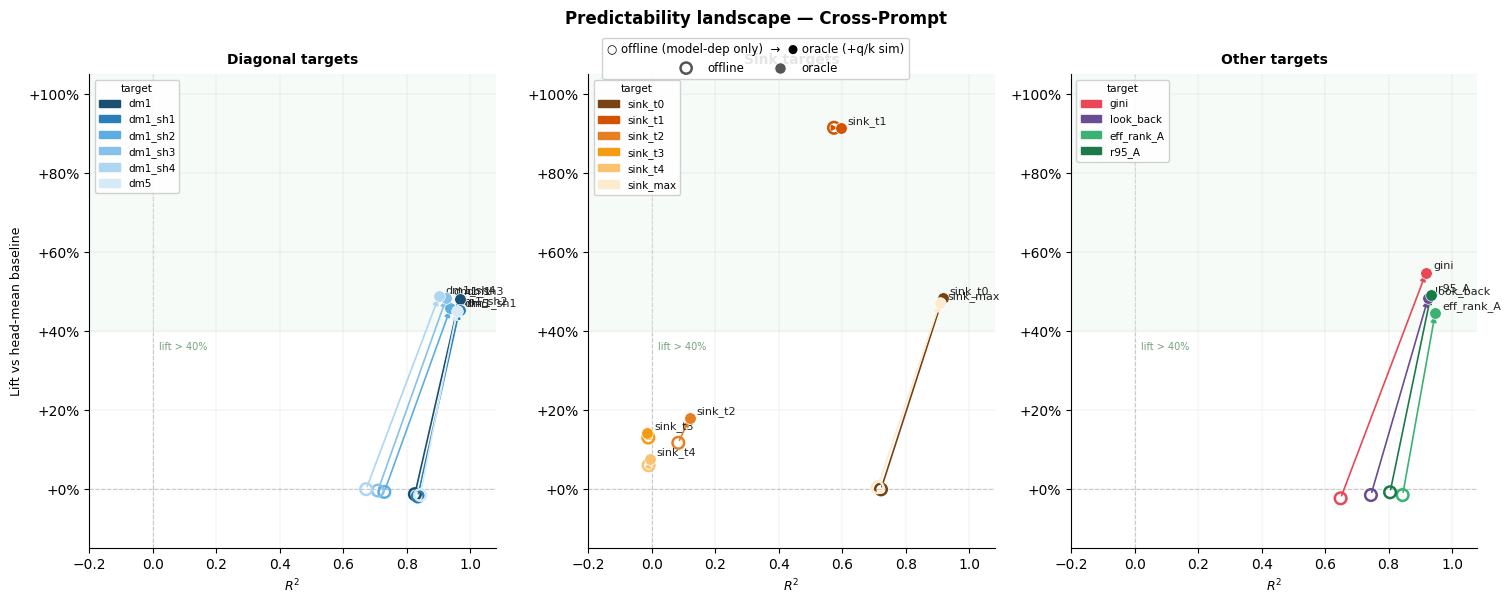

In [34]:
def plot_r2_vs_lift_panels(pivot):

    GROUPS = {
        "Diagonal targets": {
            "diagonal_mass_1":           "dm1",
            "diagonal_mass_1_shifted_1": "dm1_sh1",
            "diagonal_mass_1_shifted_2": "dm1_sh2",
            "diagonal_mass_1_shifted_3": "dm1_sh3",
            "diagonal_mass_1_shifted_4": "dm1_sh4",
            "diagonal_mass_5":           "dm5",
        },
        "Sink targets": {
            "sink_mass_token_0": "sink_t0",
            "sink_mass_token_1": "sink_t1",
            "sink_mass_token_2": "sink_t2",
            "sink_mass_token_3": "sink_t3",
            "sink_mass_token_4": "sink_t4",
            "sink_mass_max":     "sink_max",
        },
        "Other targets": {
            "attention_gini":   "gini",
            "look_back":        "look_back",
            "effective_rank_A": "eff_rank_A",
            "r95_A":            "r95_A",
        },
    }

    GROUP_COLORS = {
        "Diagonal targets": [
            "#1b4f72", "#2980b9", "#5dade2",
            "#85c1e9", "#aed6f1", "#d6eaf8",
        ],
        "Sink targets": [
            "#784212", "#d35400", "#e67e22",
            "#f39c12", "#f8c471", "#fdebd0",
        ],
        "Other targets": [
            "#E84855", "#6A4C93", "#3BB273", "#1a7a4a",
        ],
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), constrained_layout=True)

    for ax, (group_name, targets_map) in zip(axes, GROUPS.items()):
        colors = GROUP_COLORS[group_name]

        # Quadranti
        ax.axhline(0,   color="#ccc", lw=0.8, ls="--", zorder=0)
        ax.axvline(0,   color="#ccc", lw=0.8, ls="--", zorder=0)
        ax.axhspan(0.4, 1.05, color="#e8f5ea", alpha=0.35, zorder=0)
        ax.text(0.02, 0.42, "lift > 40%", fontsize=7, color="#3a7a45",
                alpha=0.7, transform=ax.get_xaxis_transform())

        handles_legend = []
        for i, (target, label) in enumerate(targets_map.items()):
            if target not in pivot.index:
                continue
            color = colors[i % len(colors)]

            r2_off   = pivot.loc[target, "R2_offline"]
            r2_ora   = pivot.loc[target, "R2_oracle"]
            lift_off = pivot.loc[target, "lift_offline"]
            lift_ora = pivot.loc[target, "lift_oracle"]

            # Freccia offline → oracle
            ax.annotate("",
                xy=(r2_ora, lift_ora), xytext=(r2_off, lift_off),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=1.2, mutation_scale=8),
                zorder=2)

            # Punto offline: vuoto
            ax.scatter(r2_off, lift_off, s=70, facecolors="none",
                       edgecolors=color, linewidths=1.8, zorder=3)

            # Punto oracle: pieno
            ax.scatter(r2_ora, lift_ora, s=70, color=color,
                       edgecolors="white", linewidths=0.5, zorder=4)

            # Label sul punto oracle
            ax.annotate(label, xy=(r2_ora, lift_ora),
                        xytext=(5, 3), textcoords="offset points",
                        fontsize=8, color="#222")

            handles_legend.append(
                mpatches.Patch(color=color, label=label)
            )

        ax.set_title(group_name, fontsize=10, fontweight="bold", pad=8)
        ax.set_xlabel("$R^2$", fontsize=9)
        ax.set_ylabel("Lift vs head-mean baseline" if ax == axes[0] else "",
                      fontsize=9)
        ax.set_xlim(-0.20, 1.08)
        ax.set_ylim(-0.15, 1.05)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f"{v:+.0%}")
        )
        ax.grid(lw=0.3, alpha=0.4)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(handles=handles_legend, fontsize=7.5,
                  loc="upper left", framealpha=0.9,
                  title="target", title_fontsize=7.5)

    # Legenda globale marker offline/oracle
    marker_handles = [
        plt.scatter([], [], s=65, facecolors="none",
                    edgecolors="#555", linewidths=1.8, label="offline"),
        plt.scatter([], [], s=65, color="#555",
                    edgecolors="white", linewidths=0.5, label="oracle"),
    ]
    fig.legend(handles=marker_handles, fontsize=8.5,
               loc="upper center", ncol=2,
               bbox_to_anchor=(0.5, 1.03),
               title="○ offline (model-dep only)  →  ● oracle (+q/k sim)",
               title_fontsize=8.5, framealpha=0.9)

    fig.suptitle("Predictability landscape — Cross-Prompt",
                 fontsize=12, fontweight="bold", y=1.07)
    plt.show()


plot_r2_vs_lift_panels(pivot)

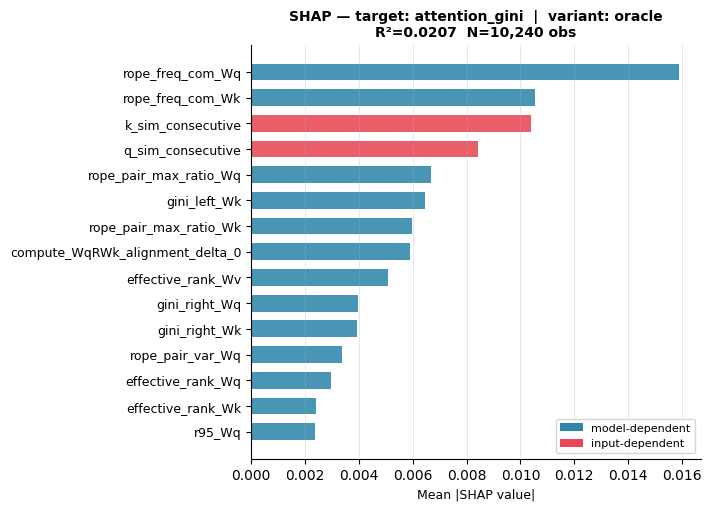

Run (sink_mass_token_0, offline) non trovata nel cache. Disponibili: [('attention_gini', 'offline'), ('attention_gini', 'oracle'), ('diagonal_mass_1', 'offline'), ('diagonal_mass_1', 'oracle'), ('diagonal_mass_5', 'offline'), ('diagonal_mass_5', 'oracle'), ('diagonal_mass_1_shifted_1', 'offline'), ('diagonal_mass_1_shifted_1', 'oracle'), ('diagonal_mass_1_shifted_2', 'offline'), ('diagonal_mass_1_shifted_2', 'oracle'), ('diagonal_mass_1_shifted_3', 'offline'), ('diagonal_mass_1_shifted_3', 'oracle')]
Run (look_back, oracle) non trovata nel cache. Disponibili: [('attention_gini', 'offline'), ('attention_gini', 'oracle'), ('diagonal_mass_1', 'offline'), ('diagonal_mass_1', 'oracle'), ('diagonal_mass_5', 'offline'), ('diagonal_mass_5', 'oracle'), ('diagonal_mass_1_shifted_1', 'offline'), ('diagonal_mass_1_shifted_1', 'oracle'), ('diagonal_mass_1_shifted_2', 'offline'), ('diagonal_mass_1_shifted_2', 'oracle'), ('diagonal_mass_1_shifted_3', 'offline'), ('diagonal_mass_1_shifted_3', 'oracle'

In [30]:
def plot_shap_run(target, variant="oracle", top_n=15):
    key = (target, variant)
    if key not in _RUN_CACHE:
        print(f"Run ({target}, {variant}) non trovata nel cache. "
              f"Disponibili: {list(_RUN_CACHE.keys())}")
        return

    cache  = _RUN_CACHE[key]
    model  = cache["model"]
    feats  = cache["feats"]
    df_te  = cache["df_pred"]

    X = df_te[feats].fillna(0).values

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X)          # shape (n_obs, n_feats)
    mean_shap = np.abs(shap_vals).mean(axis=0)

    order     = np.argsort(mean_shap)[::-1][:top_n]
    feat_ord  = [feats[i] for i in order]
    shap_ord  = mean_shap[order]
    colors    = ["#2E86AB" if f in MODEL_DEP_FEATURES else "#E84855"
                 for f in feat_ord]

    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    ax.barh(range(len(feat_ord))[::-1], shap_ord,
            color=colors, alpha=0.88, edgecolor="none", height=0.65)
    ax.set_yticks(range(len(feat_ord))[::-1])
    ax.set_yticklabels(feat_ord, fontsize=9)
    ax.set_xlabel("Mean |SHAP value|", fontsize=9)
    ax.set_title(f"SHAP — target: {target}  |  variant: {variant}\n"
                 f"R²={_RUN_CACHE[key]['df_pred']['resid'].std():.4f}  "
                 f"N={len(df_te):,} obs",
                 fontsize=10, fontweight="bold")
    ax.grid(axis="x", lw=0.4, alpha=0.5)
    ax.spines[["top","right"]].set_visible(False)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor="#2E86AB", label="model-dependent"),
        Patch(facecolor="#E84855", label="input-dependent"),
    ], fontsize=8)
    plt.show()


# Plotta SHAP per qualsiasi run
plot_shap_run("attention_gini",   variant="oracle")
plot_shap_run("sink_mass_token_0", variant="offline")
plot_shap_run("look_back",         variant="oracle")



In [10]:
from scipy.stats import spearmanr

features_to_check = ["q_sim_consecutive", "k_sim_consecutive"]
for feat in features_to_check:
    if feat in df.columns:
        rho, pval = spearmanr(df[feat].dropna(), 
                              df.loc[df[feat].notna(), "attention_gini"])
        print(f"{feat:30s}  ρ = {rho:.4f}  p = {pval:.2e}")

q_sim_consecutive               ρ = 0.1641  p = 0.00e+00
k_sim_consecutive               ρ = 0.1497  p = 0.00e+00


### Note
* genearlizzazione cross prompt okay ma solo su prompt dello stesso dataset. se addestro su random e testo su wiki fa schifo. devo provare con un altro dataset 
* INteressante che model features only faccia schifo ma qsim+ksim+model_features faccia molto molto bene



════════════════════════════════════════════════════════════
EXPERIMENT 2 — Cross-Head Generalization
════════════════════════════════════════════════════════════
Prompt source: wikitext_wikitext-103-raw-v1_train

── Variante: offline (18 features) ──
  Teste totali: 1024
  Train: 820 heads | Val: 102 heads | Test: 102 heads
  R²:              0.6326
  MAE (model):     0.01766
  MAE (global μ):  0.03005  lift=+41.2%
  MAE (1-NN):      0.02401  lift=+26.4%

── Variante: oracle (28 features) ──
  Teste totali: 1024
  Train: 820 heads | Val: 102 heads | Test: 102 heads
  R²:              0.6510
  MAE (model):     0.01639
  MAE (global μ):  0.03005  lift=+45.5%
  MAE (1-NN):      0.02401  lift=+31.7%


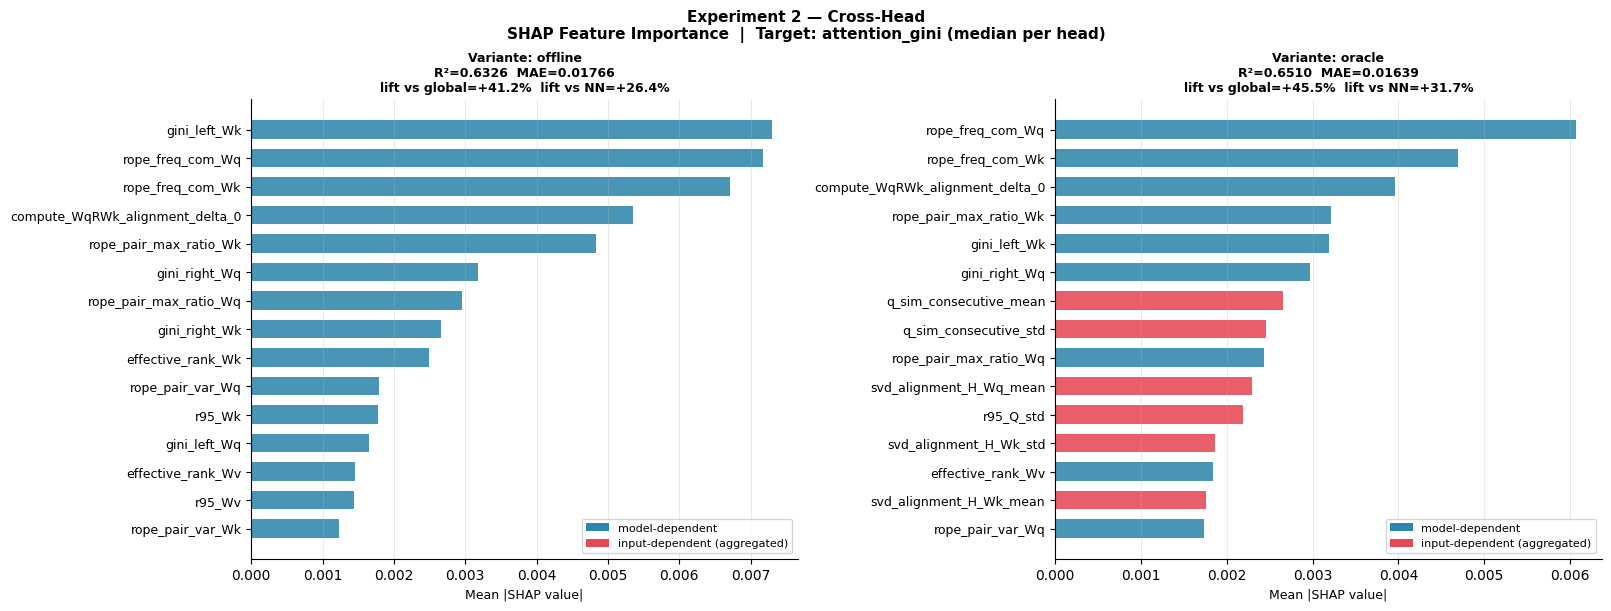

In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# ── Feature sets ──────────────────────────────────────────────────────────────
MODEL_DEP_FEATURES = [
    "effective_rank_Wq", "r95_Wq",
    "effective_rank_Wk", "r95_Wk",
    "effective_rank_Wv", "r95_Wv",
    "gini_left_Wq",  "gini_right_Wq",
    "gini_left_Wk",  "gini_right_Wk",
    "rope_pair_var_Wq",       "rope_pair_var_Wk",
    "rope_pair_max_ratio_Wq", "rope_pair_max_ratio_Wk",
    "rope_freq_com_Wq",       "rope_freq_com_Wk",
    "rmsnorm_gamma_norm",
    "compute_WqRWk_alignment_delta_0",
]

INPUT_DEP_FEATURES = [
    "effective_rank_H", "r95_H",
    "effective_rank_Q", "r95_Q",
    "effective_rank_K", "r95_K",
    "q_sim_consecutive", "k_sim_consecutive",
    "svd_alignment_H_Wq", "svd_alignment_H_Wk",
]

TARGET  = "attention_gini"
PTYPE_WIKI = "wikitext_wikitext-103-raw-v1_train"
PTYPE_RAND = "random_vocab"

FEATURE_SETS = {
    "offline": MODEL_DEP_FEATURES,
    "oracle":  MODEL_DEP_FEATURES + INPUT_DEP_FEATURES,
}

# ── Aggregazione per testa ────────────────────────────────────────────────────
def aggregate_per_head(df, features, target=TARGET):
    model_dep = [f for f in features if f in MODEL_DEP_FEATURES and f in df.columns]
    input_dep = [f for f in features if f in INPUT_DEP_FEATURES and f in df.columns]

    # Tutte le entry devono essere tuple (colonna, aggfunc)
    agg_dict = {}
    for f in model_dep:
        agg_dict[f] = (f, "first")
    for f in input_dep:
        agg_dict[f"{f}_mean"] = (f, "mean")
        agg_dict[f"{f}_std"]  = (f, "std")
    agg_dict["target_median"] = (target, "median")
    agg_dict["target_mean"]   = (target, "mean")
    agg_dict["target_std"]    = (target, "std")

    df_agg = (df.groupby(["layer_idx", "head_idx"])
                .agg(**agg_dict)
                .reset_index())

    feat_cols = (model_dep +
                 [f"{f}_mean" for f in input_dep] +
                 [f"{f}_std"  for f in input_dep])
    feat_cols = [c for c in feat_cols if c in df_agg.columns]

    return df_agg, feat_cols

# ── Split per testa ───────────────────────────────────────────────────────────
def split_by_head(df_agg, val_frac=0.10, test_frac=0.10, seed=42):
    """
    Split a livello di (layer_idx, head_idx).
    Shuffle casuale — nessun vincolo su layer depth.
    """
    heads = df_agg[["layer_idx", "head_idx"]].values
    idx   = np.arange(len(heads))
    rng   = np.random.default_rng(seed)
    rng.shuffle(idx)

    n       = len(idx)
    n_test  = max(1, int(n * test_frac))
    n_val   = max(1, int(n * val_frac))

    test_idx  = idx[:n_test]
    val_idx   = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]

    return (df_agg.iloc[train_idx].reset_index(drop=True),
            df_agg.iloc[val_idx].reset_index(drop=True),
            df_agg.iloc[test_idx].reset_index(drop=True))

# ── Baseline ──────────────────────────────────────────────────────────────────
def global_mean_baseline(df_train, df_test, target_col="target_median"):
    """Baseline: media globale del target sul train. Unica baseline valida cross-head."""
    return np.full(len(df_test), df_train[target_col].mean())

def nearest_neighbor_baseline(df_train, df_test, feat_cols, target_col="target_median"):
    """
    Baseline più forte: per ogni testa test trova la testa train
    con feature model-dep più vicine (L2) e ne usa il target.
    Usa solo MODEL_DEP_FEATURES (offline) per essere fair.
    """
    md_cols = [c for c in feat_cols if c in MODEL_DEP_FEATURES]
    if not md_cols:
        return global_mean_baseline(df_train, df_test, target_col)

    X_tr = df_train[md_cols].fillna(0).values
    X_te = df_test[md_cols].fillna(0).values

    # Normalizza per L2 fair
    mu, sigma = X_tr.mean(0), X_tr.std(0) + 1e-8
    X_tr_n = (X_tr - mu) / sigma
    X_te_n = (X_te - mu) / sigma

    preds = []
    for x in X_te_n:
        dists = np.linalg.norm(X_tr_n - x, axis=1)
        nn_idx = np.argmin(dists)
        preds.append(df_train[target_col].iloc[nn_idx])
    return np.array(preds)

# ── Training ──────────────────────────────────────────────────────────────────
def train_lgbm_head(df_train, df_val, feat_cols, target_col="target_median", seed=42):
    feats = [c for c in feat_cols if c in df_train.columns]
    X_tr, y_tr = df_train[feats].fillna(0).values, df_train[target_col].values
    X_va, y_va = df_val[feats].fillna(0).values,   df_val[target_col].values

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=feats)
    dval   = lgb.Dataset(X_va, label=y_va, reference=dtrain, feature_name=feats)

    params = {
        "objective":         "regression_l1",
        "metric":            "mae",
        "learning_rate":     0.03,
        "num_leaves":        15,          # più piccolo: 1024 obs, rischio overfit
        "feature_fraction":  0.8,
        "bagging_fraction":  0.8,
        "bagging_freq":      5,
        "min_child_samples": 5,           # meno dati per foglia rispetto a exp1
        "verbose":          -1,
        "seed":              seed,
    }

    model = lgb.train(
        params, dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )
    return model, feats

# ── Valutazione ───────────────────────────────────────────────────────────────
def evaluate_head(model, feats, df_train, df_test,
                  target_col="target_median", label=""):
    X_te   = df_test[feats].fillna(0).values
    y_te   = df_test[target_col].values
    pred   = model.predict(X_te)

    pred_global = global_mean_baseline(df_train, df_test, target_col)
    pred_nn     = nearest_neighbor_baseline(df_train, df_test, feats, target_col)

    mae_model  = mean_absolute_error(y_te, pred)
    mae_global = mean_absolute_error(y_te, pred_global)
    mae_nn     = mean_absolute_error(y_te, pred_nn)

    out = {
        "label":        label,
        "n_heads_test": len(y_te),
        "R2":           r2_score(y_te, pred),
        "MAE":          mae_model,
        "MAE_global":   mae_global,
        "MAE_nn":       mae_nn,
        "lift_global":  (mae_global - mae_model) / mae_global,
        "lift_nn":      (mae_nn     - mae_model) / mae_nn,
    }

    df_out = df_test.copy()
    df_out["pred"]  = pred
    df_out["resid"] = y_te - pred
    return out, df_out

# ── SHAP analysis ─────────────────────────────────────────────────────────────
def plot_shap_crosshead(results_ch, top_n=15):
    n_variants = len(results_ch)
    fig, axes  = plt.subplots(1, n_variants, figsize=(8 * n_variants, 6),
                               constrained_layout=True)
    if n_variants == 1:
        axes = [axes]

    for ax, (var_name, res) in zip(axes, results_ch.items()):
        model  = res["model"]
        feats  = res["feats"]
        X_test = res["preds"][feats].fillna(0).values

        explainer  = shap.TreeExplainer(model)
        shap_vals  = explainer.shap_values(X_test)
        mean_shap  = np.abs(shap_vals).mean(axis=0)
        order      = np.argsort(mean_shap)[::-1][:top_n]

        feat_ord  = [feats[i] for i in order]
        shap_ord  = mean_shap[order]
        colors    = ["#2E86AB" if f in MODEL_DEP_FEATURES else "#E84855"
                     for f in feat_ord]

        ax.barh(range(len(feat_ord))[::-1], shap_ord,
                color=colors, alpha=0.88, edgecolor="none", height=0.65)
        ax.set_yticks(range(len(feat_ord))[::-1])
        ax.set_yticklabels(feat_ord, fontsize=9)
        ax.set_xlabel("Mean |SHAP value|", fontsize=9)

        m = res["metrics"]
        ax.set_title(
            f"Variante: {var_name}\n"
            f"R²={m['R2']:.4f}  MAE={m['MAE']:.5f}\n"
            f"lift vs global={m['lift_global']:+.1%}  "
            f"lift vs NN={m['lift_nn']:+.1%}",
            fontsize=9, fontweight="bold"
        )
        ax.grid(axis="x", lw=0.4, alpha=0.5)
        ax.spines[["top","right"]].set_visible(False)

        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(facecolor="#2E86AB", label="model-dependent"),
            Patch(facecolor="#E84855", label="input-dependent (aggregated)"),
        ], fontsize=8, loc="upper left")

    fig.suptitle(
        "Experiment 2 — Cross-Head\n"
        "SHAP Feature Importance  |  Target: attention_gini (median per head)",
        fontsize=11, fontweight="bold"
    )
    plt.show()

# ── Esecuzione ────────────────────────────────────────────────────────────────
def run_cross_head_experiment(df, prompt_source=None, seed=42):
    print("\n" + "═"*60)
    print("EXPERIMENT 2 — Cross-Head Generalization")
    print("═"*60)

    if prompt_source:
        df = df[df["prompt_source"] == prompt_source].copy()
        print(f"Prompt source: {prompt_source}")

    results_ch = {}
    for var_name, feats in FEATURE_SETS.items():
        feats_avail = [f for f in feats if f in df.columns]
        print(f"\n── Variante: {var_name} ({len(feats_avail)} features) ──")

        # Aggrega per testa
        df_agg, feat_cols = aggregate_per_head(df, feats_avail)
        print(f"  Teste totali: {len(df_agg)}")

        # Split per testa
        df_tr, df_va, df_te = split_by_head(df_agg, seed=seed)
        print(f"  Train: {len(df_tr)} heads | Val: {len(df_va)} heads | "
              f"Test: {len(df_te)} heads")

        # Training
        model, feats_used = train_lgbm_head(df_tr, df_va, feat_cols, seed=seed)

        # Valutazione
        metrics, df_pred = evaluate_head(
            model, feats_used, df_tr, df_te, label=f"CH/{var_name}"
        )

        print(f"  R²:              {metrics['R2']:.4f}")
        print(f"  MAE (model):     {metrics['MAE']:.5f}")
        print(f"  MAE (global μ):  {metrics['MAE_global']:.5f}  "
              f"lift={metrics['lift_global']:+.1%}")
        print(f"  MAE (1-NN):      {metrics['MAE_nn']:.5f}  "
              f"lift={metrics['lift_nn']:+.1%}")

        results_ch[var_name] = {
            "model": model, "feats": feats_used,
            "metrics": metrics, "preds": df_pred,
            "df_train": df_tr,
        }

    # SHAP finale
    plot_shap_crosshead(results_ch, top_n=15)
    return results_ch


# ── Run ───────────────────────────────────────────────────────────────────────
results_ch = run_cross_head_experiment(df, prompt_source=PTYPE_WIKI)